# Statistical Validation of Age Progression Scores from Optimal Transport Alignment

---

## Table of Contents

- **1. Setup and Imports** — Library imports and configuration
- **2. Configuration** — Paths, parameters, and experimental settings
- **3. Core Functions** — Data I/O, distance calculations, OT wrappers
  - 3.1 Data Loading Utilities
  - 3.2 Cosine Distance Computation Function
  - 3.3 Optimal Transport Plan Computation
  - 3.4 Per-Cell-Type Score Averaging
- **4. Combined Gene-Specific Cell Type Noise Sensitivity Test**
  - 4.1 Rationale
  - 4.2 Helper Functions
  - 4.3 Main Test Function
  - 4.4 Visualization Function (Single Plot per Cell Type)
  - 4.5 Execute Combined Test

---

## Methods Overview

### Age Progression Score

The age progression score quantifies cellular aging by measuring the transport cost between young and aged samples:

$$\text{Score} = \sum_{i,j} \pi_{ij} \cdot d(c_i^{\text{young}}, c_j^{\text{aged}}) \times n_{\text{cells}} \times 100$$

where:
- $\pi_{ij}$ = optimal transport plan element (probability of matching cell $i$ to cell $j$)
- $d(\cdot, \cdot)$ = cosine distance incorporating gene expression and cell type
- $n_{\text{cells}}$ = normalization factor

### Cosine Distance with Cell Type Weighting

$$d(c_i, c_j) = 1 - \cos\left([\mathbf{x}_i, \beta \cdot \mathbf{t}_i], [\mathbf{x}_j, \beta \cdot \mathbf{t}_j]\right)$$

where $\mathbf{x}$ is gene expression, $\mathbf{t}$ is one-hot cell type encoding, and $\beta$ is the cell-type weighting parameter (default: 0.8).

### Statistical Framework

All tests use permutation-based null distributions with empirical p-values computed as:

$$p = \frac{b + 1}{m + 1}$$

where $b$ = count of permuted statistics ≥ observed, $m$ = number of permutations.

## 1. Setup and Imports

In [1]:
import matplotlib.pyplot as plt
import scanpy as sc
import numpy as np
import pandas as pd
import os
from sklearn.metrics.pairwise import cosine_distances
from scipy.sparse import issparse
from tqdm import tqdm
import warnings
import ot
import pickle
import gc
warnings.filterwarnings('ignore')

# Import INCENT functions
try:
    import paste as pst
    print("INCENT modules imported successfully!")
except ImportError as e:
    print(f"Warning: Could not import INCENT modules: {e}")
    print("Falling back to standalone OT implementation")

# Set random seed for reproducibility
np.random.seed(42)

print("Libraries imported successfully!")

INCENT modules imported successfully!
Libraries imported successfully!


## 2. Configuration

In [2]:
# =============================================================================
# CONFIGURATION
# =============================================================================

# --- Directory Paths ---
DATA_DIR = './data/dummy_test/'      # MERFISH spatial transcriptomics data
FILE_PATH = './local_data/incent'              # Pre-computed OT alignment matrices
SAVE_DIR = './local_data/statistical_analysis' # Output directory for figures/results

# Create output directory
os.makedirs(SAVE_DIR, exist_ok=True)

# --- Permutation Test Parameters ---
N_PERMUTATIONS = 100 # Number of permutations used for empirical null validation
ALPHA = 0.05           # Significance level (Type I error rate)
BETA = 0.8             # Cell type weighting in cosine distance

# --- Sample Selection ---
AGE_START = '4'        # Reference age (weeks)
AGE_END = '24'         # Target age (weeks)

# --- Print Configuration Summary ---
print("=" * 60)
print("STATISTICAL VALIDATION CONFIGURATION")
print("=" * 60)
print(f"\nData Paths:")
print(f"  MERFISH data:      {DATA_DIR}")
print(f"  OT matrices:       {FILE_PATH}")
print(f"  Output directory:  {SAVE_DIR}")
print(f"\nStatistical Parameters:")
print(f"  Permutations:      {N_PERMUTATIONS}")
print(f"  Significance (α):  {ALPHA}")
print(f"  Cell type weight:  β = {BETA}")
print(f"\nSample Ages:")
print(f"  Reference:         {AGE_START} weeks")
print(f"  Target:            {AGE_END} weeks")
print("=" * 60)

STATISTICAL VALIDATION CONFIGURATION

Data Paths:
  MERFISH data:      ./data/dummy_test/
  OT matrices:       ./local_data/incent
  Output directory:  ./local_data/statistical_analysis

Statistical Parameters:
  Permutations:      5
  Significance (α):  0.05
  Cell type weight:  β = 0.8

Sample Ages:
  Reference:         4 weeks
  Target:            24 weeks


---

## 3. Core Functions

### 3.1 Data Loading Utilities

Functions for loading MERFISH data and pre-computed optimal transport matrices.

In [3]:
def load_slice_data(data_dir, sample_name):
    """Load a single slice from h5ad file."""
    file_path = os.path.join(data_dir, f"{sample_name}.h5ad")
    return sc.read_h5ad(file_path)

def load_precomputed_matrices(file_path, data1, data2):
    """Load pre-computed pi matrix and cosine distance matrix."""
    pi_mat = np.load(f"{file_path}/pi_matrix_{data1}_{data2}.npy")
    cosine_dist = np.load(f"{file_path}/cosine_dist_gene_expr_{data1}_{data2}.npy")
    return pi_mat, cosine_dist

def compute_age_progression_score(pi_mat, cosine_dist, n_cells_source, n_cells_target):
    """
    Compute age progression score from pi matrix and cosine distance.

    Returns:
        scores_source: Age progression scores for source (reference) cells
        scores_target: Age progression scores for target cells
    """
    age_score_mat = pi_mat * cosine_dist

    # Scores for source cells (sum over columns)
    scores_source = np.sum(age_score_mat, axis=1) / (1 / n_cells_source) * 100

    # Scores for target cells (sum over rows)
    scores_target = np.sum(age_score_mat, axis=0) / (1 / n_cells_target) * 100

    return scores_source, scores_target

print("Data loading functions defined.")

Data loading functions defined.


### 3.2 Cosine Distance Computation Function

In [4]:
def compute_cosine_distance_matrix(sliceA, sliceB, beta=0.8):
    """
    Compute cosine distance matrix between two slices.

    This replicates the logic from helper.cosine_dist_calculator:
    - Gene expression matrix + beta * one-hot cell type encoding
    - Cosine distance between all cell pairs

    Args:
        sliceA: AnnData object for reference slice
        sliceB: AnnData object for target slice
        beta: Weight for cell type one-hot encoding (default: 0.8)

    Returns:
        cosine_dist: (n_cells_A x n_cells_B) cosine distance matrix
    """
    # Extract gene expression (dense matrix)
    A_X = sliceA.X.toarray() if hasattr(sliceA.X, 'toarray') else np.array(sliceA.X)
    B_X = sliceB.X.toarray() if hasattr(sliceB.X, 'toarray') else np.array(sliceB.X)

    # Add small constant to avoid division by zero
    s_A = A_X + 0.01
    s_B = B_X + 0.01

    # Get one-hot encoded cell types
    one_hot_A = pd.get_dummies(sliceA.obs['cell_type_annot']).to_numpy()
    one_hot_B = pd.get_dummies(sliceB.obs['cell_type_annot']).to_numpy()

    # Ensure same columns (cell types) in both
    all_cell_types = list(set(sliceA.obs['cell_type_annot'].unique()) |
                          set(sliceB.obs['cell_type_annot'].unique()))

    one_hot_A = pd.get_dummies(sliceA.obs['cell_type_annot']).reindex(columns=all_cell_types, fill_value=0).to_numpy()
    one_hot_B = pd.get_dummies(sliceB.obs['cell_type_annot']).reindex(columns=all_cell_types, fill_value=0).to_numpy()

    # Concatenate gene expression with weighted cell type encoding
    s_A = np.concatenate((s_A, beta * one_hot_A), axis=1)
    s_B = np.concatenate((s_B, beta * one_hot_B), axis=1)

    # Compute cosine distance
    cosine_dist = cosine_distances(s_A, s_B)

    return cosine_dist

print("Cosine distance function defined.")

Cosine distance function defined.


### 3.3 Optimal Transport Plan Computation


In [5]:
def compute_optimal_transport_plan(
    sliceA,
    sliceB,
    beta=0.8,
    alpha=0.1,
    gamma=0.0,
    radius=100,
    use_gpu=True,
    numItermax=200,
    verbose=False,
    filePath='./local_data/incent_temp'
):
    """
    Compute optimal transport plan between two slices using INCENT's pairwise_align_incent.

    This directly calls the INCENT implementation from the incent module,
    ensuring consistency with script_1.py.

    Args:
        sliceA: Source AnnData object
        sliceB: Target AnnData object
        beta: Weight for cell type encoding in cosine distance (default: 0.8)
        alpha: Weight balancing spatial vs feature costs in FGW (default: 0.1)
        gamma: Weight for neighborhood dissimilarity (default: 0.0 for speed)
        radius: Radius for cellular neighborhood (default: 100, ignored if gamma=0)
        use_gpu: Use GPU acceleration (requires PyTorch with CUDA)
        numItermax: Maximum iterations for optimization
        verbose: Print progress
        filePath: Temporary directory for caching

    Returns:
        pi_mat: Optimal transport plan (n_A x n_B)
    """
    try:
        # Use INCENT's implementation directly
        os.makedirs(filePath, exist_ok=True)

        backend = ot.backend.TorchBackend() if use_gpu else ot.backend.NumpyBackend()

        pi_mat = pst.pairwise_align_incent(
            sliceA=sliceA,
            sliceB=sliceB,
            alpha=alpha,
            beta=beta,
            gamma=gamma,
            radius=radius,
            filePath=filePath,
            dissimilarity='jsd',
            use_rep=None,
            G_init=None,
            a_distribution=None,
            b_distribution=None,
            norm=False,
            numItermax=numItermax,
            backend=backend,
            use_gpu=use_gpu,
            return_obj=False,
            verbose=verbose,
            gpu_verbose=False,
            sliceA_name='sliceA_temp',
            sliceB_name='sliceB_temp',
            overwrite=True,
            neighborhood_dissimilarity='jsd'
        )

        if verbose:
            transported_mass = pi_mat.sum()
            print(f"Transported mass: {transported_mass:.4f}")
            print(f"Mean entry: {pi_mat.mean():.2e}")

        return pi_mat

    except NameError:
        # Fallback if INCENT not imported - use simplified OT
        if verbose:
            print("INCENT module not available, using simplified OT")

        n_source = sliceA.n_obs
        n_target = sliceB.n_obs

        # Simplified entropic OT with cosine distance
        if hasattr(sliceA.X, 'toarray'):
            A_X = sliceA.X.toarray()
        else:
            A_X = np.array(sliceA.X)

        if hasattr(sliceB.X, 'toarray'):
            B_X = sliceB.X.toarray()
        else:
            B_X = np.array(sliceB.X)

        # One-hot encode cell types
        all_cell_types = sorted(set(sliceA.obs['cell_type_annot'].unique()) |
                               set(sliceB.obs['cell_type_annot'].unique()))

        one_hot_A = pd.get_dummies(sliceA.obs['cell_type_annot']).reindex(
            columns=all_cell_types, fill_value=0).to_numpy()
        one_hot_B = pd.get_dummies(sliceB.obs['cell_type_annot']).reindex(
            columns=all_cell_types, fill_value=0).to_numpy()

        A_aug = np.concatenate([A_X, beta * one_hot_A], axis=1)
        B_aug = np.concatenate([B_X, beta * one_hot_B], axis=1)

        M = cosine_distances(A_aug, B_aug)
        M = M - M.min()
        M = M / (M.mean() + 1e-8)

        a = np.ones(n_source) / n_source
        b = np.ones(n_target) / n_target

        pi_mat = ot.sinkhorn(a, b, M, reg=0.05, numItermax=numItermax)

        return np.array(pi_mat)

print("Optimal transport computation using INCENT module defined.")

Optimal transport computation using INCENT module defined.


### 3.4 Per-Cell-Type Score Averaging


In [6]:
def compute_avg_score_per_cell_type(
    adata_source: sc.AnnData,
    scores: np.ndarray,
    cell_type_col: str = 'cell_type_annot'
) -> dict:
    """
    Compute average age progression score per cell type.
    
    Parameters
    ----------
    adata_source : AnnData
        Source data with cell type annotations
    scores : np.ndarray
        Age progression scores (one per cell)
    cell_type_col : str
        Column name for cell types
        
    Returns
    -------
    avg_scores : dict
        {cell_type: avg_score}
    """
    cell_types = adata_source.obs[cell_type_col].values
    unique_types = np.unique(cell_types)
    
    avg_scores = {}
    for ct in unique_types:
        mask = cell_types == ct
        avg_scores[ct] = np.mean(scores[mask])
    
    return avg_scores


print("Helper functions for synthetic noise test defined.")

Helper functions for synthetic noise test defined.


---

## 4. Combined Gene-Specific Cell Type Noise Sensitivity Test

### 4.1 Rationale

This test combines the results of all noise multipliers (1x, 2x, 3x) into a single visualization per cell type. This allows for direct comparison of how increasing noise levels affect the robustness of the age progression score.

**Methodology**:
1. Generate synthetic sources for multiple noise levels (e.g., 100 slices each for 1x, 2x, and 3x multipliers, totaling 300 slices).
2. Compute original and synthetic age progression scores.
3. Plot the distributions of all noise levels together in a single graph per cell type overlaid with the original score.



### 4.2 Helper Functions

In [7]:
def compute_gene_specific_std_per_cell_type(
    adata: sc.AnnData,
    cell_type_col: str = 'cell_type_annot'
) -> dict:
    """
    Compute gene-specific standard deviation for each cell type.
    
    This creates a matrix of std values: cell_type × gene
    
    Parameters
    ----------
    adata : AnnData
        Input data
    cell_type_col : str
        Column name with cell type annotations
        
    Returns
    -------
    std_per_type_per_gene : dict
        {cell_type: std_array} where std_array is shape (n_genes,)
        Each element std_array[i] is the std of gene i for that cell type
    """
    if issparse(adata.X):
        expr = adata.X.toarray()
    else:
        expr = np.array(adata.X)
    
    cell_types = adata.obs[cell_type_col].values
    unique_types = np.unique(cell_types)
    
    std_per_type_per_gene = {}
    for ct in unique_types:
        mask = cell_types == ct
        ct_expr = expr[mask, :]
        # Compute std for each gene (axis=0) within this cell type
        std_per_type_per_gene[ct] = np.std(ct_expr, axis=0)
    
    return std_per_type_per_gene


def generate_synthetic_adata_gene_specific(
    adata: sc.AnnData,
    std_per_type_per_gene: dict,
    noise_multiplier: float = 1.0,
    cell_type_col: str = 'cell_type_annot',
    random_seed: int = None
) -> sc.AnnData:
    """
    Generate synthetic AnnData with gene-specific, cell type-specific Gaussian noise.
    
    Parameters
    ----------
    adata : AnnData
        Source data
    std_per_type_per_gene : dict
        {cell_type: std_array} from compute_gene_specific_std_per_cell_type
        std_array has shape (n_genes,)
    noise_multiplier : float
        Multiplier for std (e.g., 1.0, 2.0, 3.0)
    cell_type_col : str
        Column with cell type annotations
    random_seed : int
        Random seed for reproducibility
        
    Returns
    -------
    synthetic_adata : AnnData
        Copy of adata with gene-specific, cell type-specific noisy gene expression
    """
    rng = np.random.default_rng(random_seed)
    
    # Create a copy
    synthetic = adata.copy()
    
    # Get expression matrix
    if issparse(adata.X):
        expr = adata.X.toarray()
    else:
        expr = np.array(adata.X)
    
    # Get cell types
    cell_types = adata.obs[cell_type_col].values
    
    # Add gene-specific, cell type-specific noise
    noisy_expr = expr.copy()
    for i, ct in enumerate(cell_types):
        # Get std array for this cell type (shape: n_genes)
        std_for_type = std_per_type_per_gene[ct]
        
        # Generate noise for each gene: N(0, noise_multiplier × std[gene])
        # This preserves gene-specific variability within the cell type
        noise = rng.normal(0, noise_multiplier * std_for_type, size=std_for_type.shape)
        
        # Add noise to this cell
        noisy_expr[i, :] += noise
    
    # Clip negative values
    noisy_expr = np.maximum(noisy_expr, 0)
    
    # Update synthetic adata
    synthetic.X = noisy_expr
    
    return synthetic


print("Helper functions for gene-specific cell type noise test defined.")

Helper functions for gene-specific cell type noise test defined.


### 4.3 Main Test Function


In [8]:
def gene_specific_cell_type_noise_test_combined(
    source_name: str,
    target_name: str,
    data_dir: str,
    n_synthetic: int = 100,
    noise_multipliers: list = [1.0, 2.0, 3.0],
    beta: float = 0.8,
    cell_type_col: str = 'cell_type_annot',
    random_seed: int = 42,
    save_dir: str = None,
    ot_params: dict = None
) -> dict:
    """
    Test sensitivity using gene-specific, cell type-specific noise, returning combined results.
    Similar to Section 14, but intended for combined visualization.
    """
    if ot_params is None:
        ot_params = {
            'beta': beta,
            'alpha': 0.1,
            'numItermax': 200,
            'use_gpu': True
        }
    
    print(f"\n{'='*70}")
    print(f"COMBINED GENE-SPECIFIC CELL TYPE NOISE SENSITIVITY TEST")
    print(f"{'='*70}")
    print(f"Source: {source_name}")
    print(f"Target: {target_name}")
    print(f"N synthetic per noise level: {n_synthetic} (Total: {n_synthetic * len(noise_multipliers)})")
    print(f"Noise levels: {noise_multipliers} × gene-specific, cell type-specific std")
    print(f"{'='*70}\n")
    
    print("Loading data...")
    source = load_slice_data(data_dir, source_name)
    target = load_slice_data(data_dir, target_name)
    
    n_source = source.n_obs
    n_target = target.n_obs
    n_genes = source.n_vars
    cell_types = np.unique(source.obs[cell_type_col])
    
    # Compute std
    print("\nComputing gene-specific std for each cell type...")
    std_per_type_per_gene = compute_gene_specific_std_per_cell_type(source, cell_type_col)
    
    # Original comparison
    print("Computing original optimal transport...")
    original_dist = compute_cosine_distance_matrix(source, target, beta=beta)
    original_pi = compute_optimal_transport_plan(source, target, verbose=False, **ot_params)
    original_scores, _ = compute_age_progression_score(original_pi, original_dist, n_source, n_target)
    original_avg_per_ct = compute_avg_score_per_cell_type(source, original_scores, cell_type_col)
    
    del original_dist, original_pi
    gc.collect()
    
    results = {
        'source_name': source_name,
        'target_name': target_name,
        'std_per_type': {ct: np.mean(std_per_type_per_gene[ct]) for ct in cell_types},
        'n_synthetic': n_synthetic,
        'n_genes': n_genes,
        'noise_multipliers': noise_multipliers,
        'cell_types': list(cell_types),
        'original_avg_per_ct': original_avg_per_ct,
        'noise_results': {}
    }
    
    base_rng = np.random.default_rng(random_seed)
    
    for noise_mult in noise_multipliers:
        print(f"\nProcessing NOISE LEVEL: {noise_mult}x")
        synthetic_avg_per_ct = {ct: [] for ct in cell_types}
        
        for i in range(n_synthetic):
            seed = base_rng.integers(1e9)
            synthetic_source = generate_synthetic_adata_gene_specific(
                source, std_per_type_per_gene, noise_mult, cell_type_col, seed
            )
            synthetic_dist = compute_cosine_distance_matrix(source, synthetic_source, beta=beta)
            try:
                synthetic_pi = compute_optimal_transport_plan(source, synthetic_source, verbose=False, **ot_params)
            except Exception:
                synthetic_pi = np.ones((n_source, n_source)) / (n_source * n_source)
            synthetic_scores, _ = compute_age_progression_score(synthetic_pi, synthetic_dist, n_source, n_source)
            synthetic_avg = compute_avg_score_per_cell_type(source, synthetic_scores, cell_type_col)
            
            for ct in cell_types:
                synthetic_avg_per_ct[ct].append(synthetic_avg[ct])
            
            del synthetic_source, synthetic_dist, synthetic_pi, synthetic_scores
            if (i + 1) % 10 == 0:
                print(f"  Completed {i+1}/{n_synthetic} synthetic datasets")
        gc.collect()
        for ct in cell_types:
            synthetic_avg_per_ct[ct] = np.array(synthetic_avg_per_ct[ct])
        results['noise_results'][noise_mult] = {
            'noise_multiplier': noise_mult,
            'synthetic_avg_per_ct': synthetic_avg_per_ct
        }
    
    if save_dir:
        os.makedirs(save_dir, exist_ok=True)
        save_path = os.path.join(save_dir, f"combined_noise_results_{source_name}_{target_name}.pkl")
        import pickle
        with open(save_path, 'wb') as f:
            pickle.dump(results, f)
    
    return results



### 4.4 Visualization Function (Single Plot per Cell Type)


In [9]:
def visualize_combined_noise_test(results: dict, save_path: str = None):
    """
    Visualize gene-specific cell type noise sensitivity test results in a single plot per cell type.
    Overlays all noise multipliers in a stacked histogram so the total count reaches the combined total (e.g. 300).
    """
    cell_types = results['cell_types']
    noise_multipliers = results['noise_multipliers']
    original_avg = results['original_avg_per_ct']
    
    n_cell_types = len(cell_types)
    cols = 3
    rows = int(np.ceil(n_cell_types / cols))
    
    fig, axes = plt.subplots(rows, cols, figsize=(5 * cols, 4 * rows))
    axes = axes.flatten()
    
    colors = ['#1f77b4', '#ff7f0e', '#2ca02c', '#d62728', '#9467bd']
    
    for idx, ct in enumerate(cell_types):
        ax = axes[idx]
        original_score = original_avg[ct]
        
        all_synth = []
        multipliers_data = []
        labels = []
        
        for nm in noise_multipliers:
            scores = results['noise_results'][nm]['synthetic_avg_per_ct'][ct]
            all_synth.extend(scores)
            multipliers_data.append(scores)
            labels.append(f'Noise {nm}x')
            
        x_min = min(np.min(all_synth), original_score)
        x_max = max(np.max(all_synth), original_score)
        x_range = x_max - x_min
        x_min -= 0.1 * x_range
        x_max += 0.1 * x_range
        
        # Plot as a stacked histogram so the counts add up
        ax.hist(
            multipliers_data, bins=30, range=(x_min, x_max), alpha=0.8,
            color=colors[:len(noise_multipliers)], label=labels, stacked=True
        )
            
        ax.axvline(original_score, color='red', linestyle='--', linewidth=2.5, label=f'Original: {original_score:.3f}', zorder=10)
        
        ax.set_title(ct, fontsize=12, fontweight='bold')
        ax.set_xlabel('Avg Age Progression Score')
        ax.set_ylabel('Count')
        ax.legend(fontsize=8)
        ax.grid(alpha=0.3)
        ax.set_xlim(x_min, x_max)
        
    for idx in range(n_cell_types, len(axes)):
        fig.delaxes(axes[idx])
        
    fig.suptitle(
        f'Combined Synthetic Noise Sensitivity Test (Stacked)\n'
        f'{results["source_name"]} → {results["target_name"]}',
        fontsize=14, fontweight='bold', y=1.02
    )
    plt.tight_layout()
    
    if save_path:
        plt.savefig(save_path, dpi=150, bbox_inches='tight')
        print(f"Figure saved to: {save_path}")
    plt.show()

### 4.5 Execute Combined Test


In [12]:
# ============================================================
# HARDCODED SAMPLE PAIRS FOR GENE-SPECIFIC TEST
# ============================================================

DATA_DIR = './data/Mouse_brain_MERFISH/'

SAMPLE_PAIRS_GENE = [
    {
        'source': 'adata4wk_donor_id_4_slice_0',
        'target': 'adata24wk_donor_id_11_slice_2',
        'description': '4wk slice_0 → 24wk slice_2  '
    },
    {
        'source': 'adata24wk_donor_id_11_slice_2',
        'target': 'adata90wk_donor_id_6_slice_2',
        'description': '24wk slice_2 → 90wk slice_2'
    }
]


# Test parameters
N_SYNTHETIC_GENE = 100  # Number of synthetic datasets per noise level
NOISE_LEVELS_GENE = [1.0, 2.0, 3.0]  # Gene-specific, cell type-specific noise multipliers
RANDOM_SEED_GENE = 42

print(f"Configured {len(SAMPLE_PAIRS_GENE)} sample pairs for gene-specific testing")
print(f"N_SYNTHETIC_GENE = {N_SYNTHETIC_GENE}")
print(f"NOISE_LEVELS_GENE = {NOISE_LEVELS_GENE}")

Configured 2 sample pairs for gene-specific testing
N_SYNTHETIC_GENE = 100
NOISE_LEVELS_GENE = [1.0, 2.0, 3.0]




################################################################################
# PROCESSING PAIR 1/2 COMBINED
# 4wk slice_0 → 24wk slice_2  
################################################################################


COMBINED GENE-SPECIFIC CELL TYPE NOISE SENSITIVITY TEST
Source: adata4wk_donor_id_4_slice_0
Target: adata24wk_donor_id_11_slice_2
N synthetic per noise level: 100 (Total: 300)
Noise levels: [1.0, 2.0, 3.0] × gene-specific, cell type-specific std

Loading data...

Computing gene-specific std for each cell type...
Computing original optimal transport...
Saving cosine dist of gene expression for slice A and slice B

Processing NOISE LEVEL: 1.0x
Saving cosine dist of gene expression for slice A and slice B
Saving cosine dist of gene expression for slice A and slice B
Saving cosine dist of gene expression for slice A and slice B
Saving cosine dist of gene expression for slice A and slice B
Saving cosine dist of gene expression for slice A and slice B
Saving cosine di

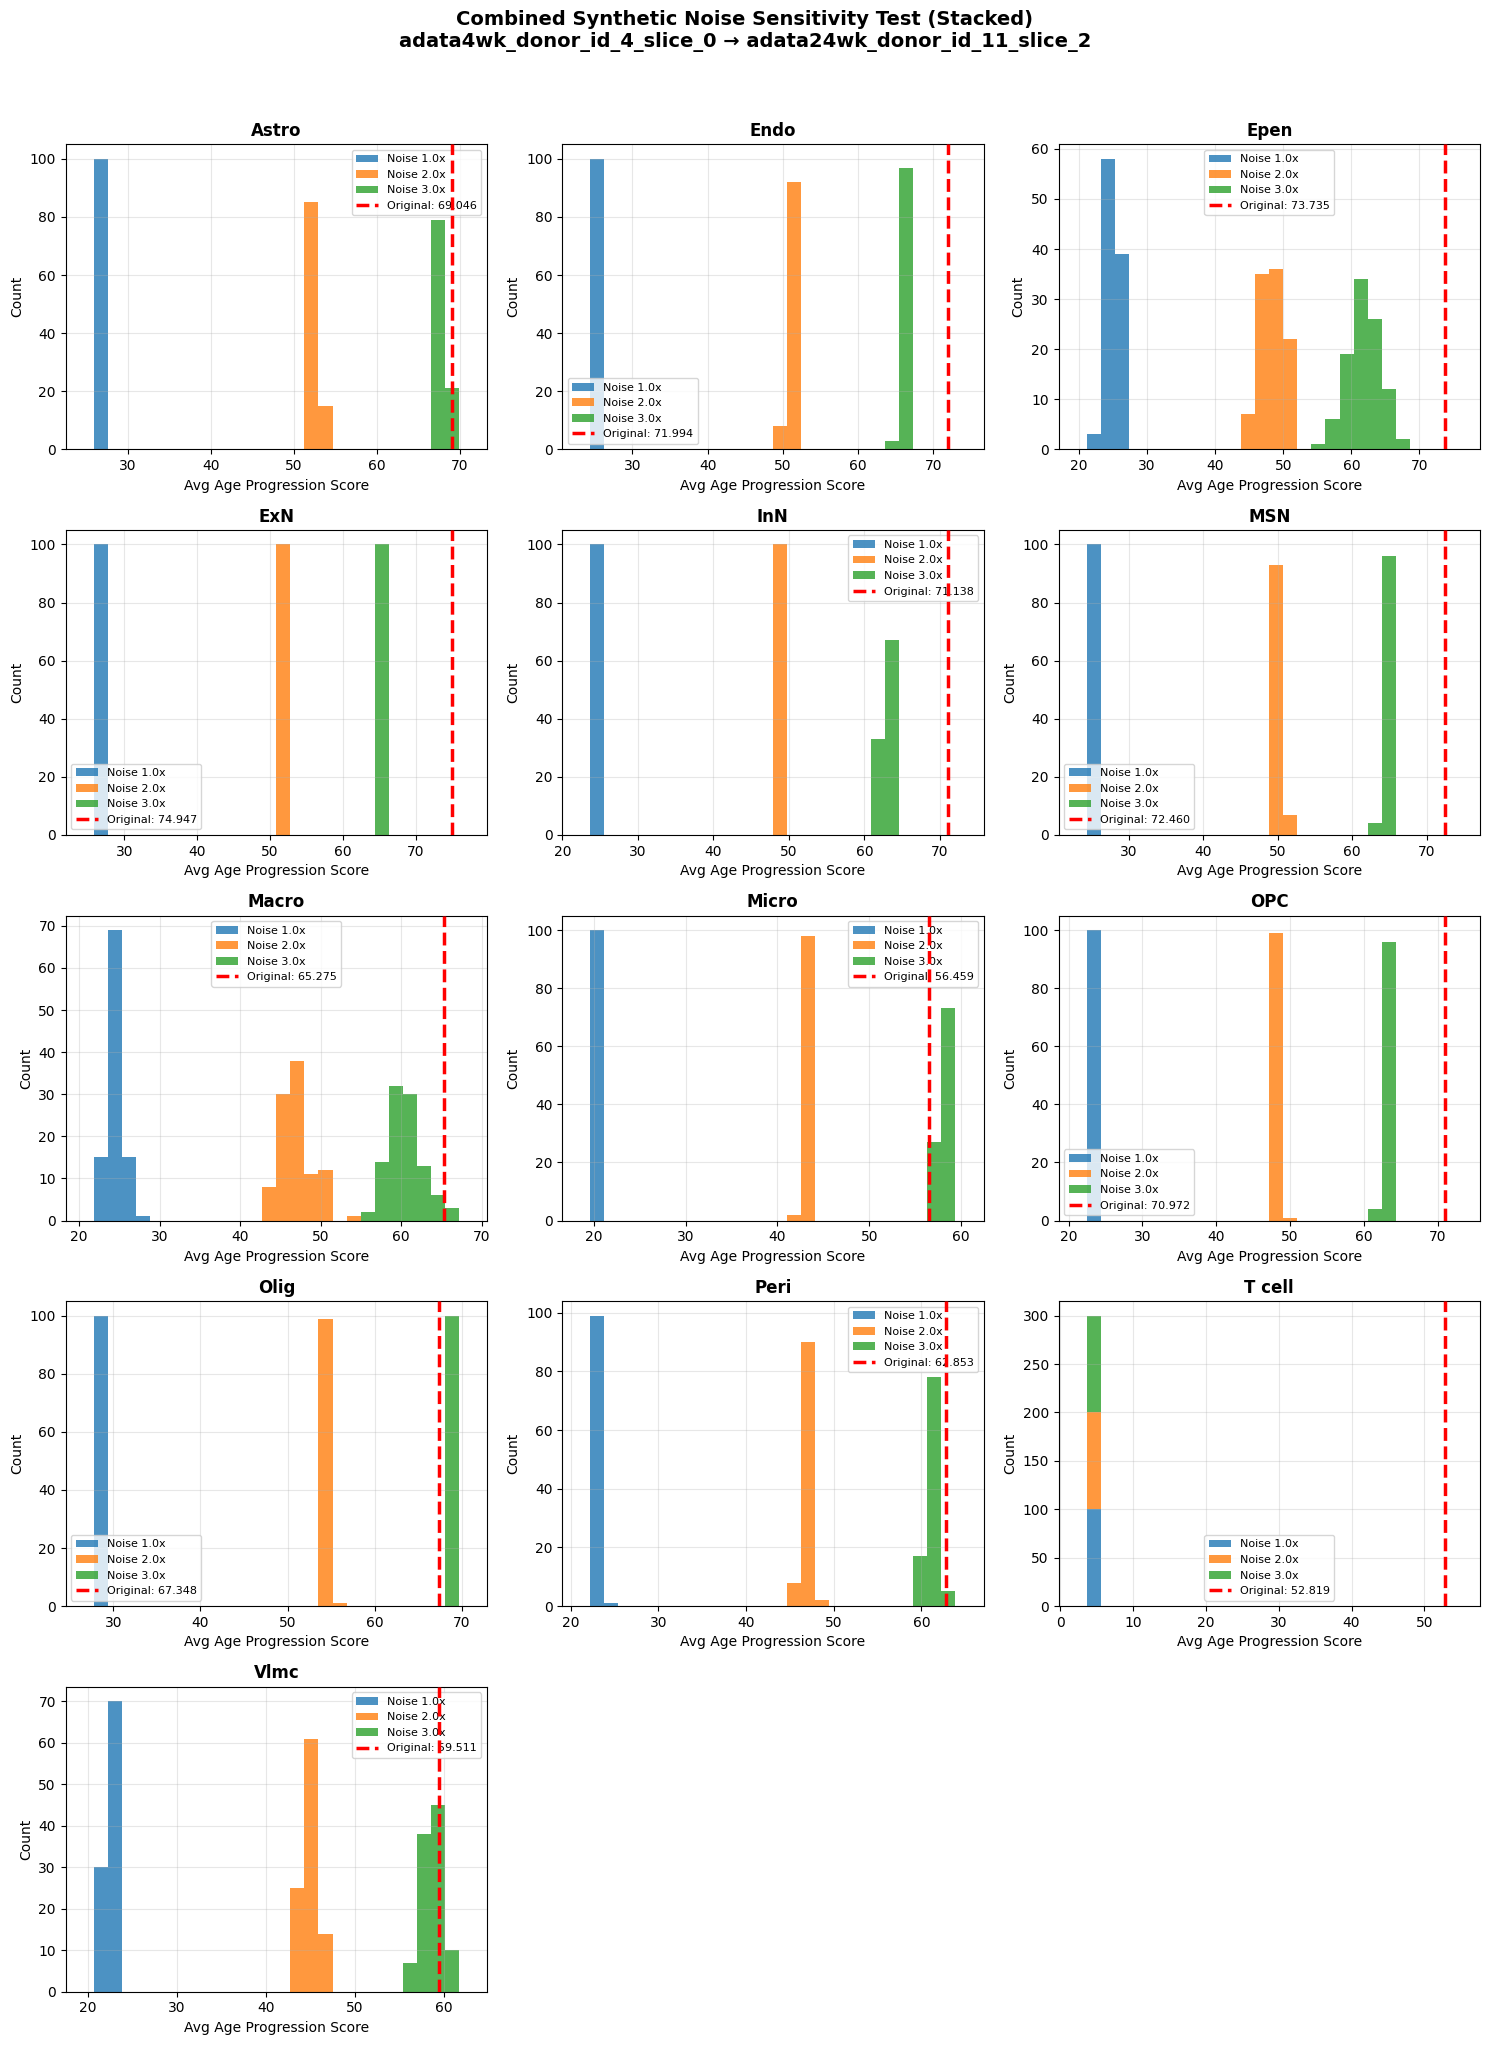



################################################################################
# PROCESSING PAIR 2/2 COMBINED
# 24wk slice_2 → 90wk slice_2
################################################################################


COMBINED GENE-SPECIFIC CELL TYPE NOISE SENSITIVITY TEST
Source: adata24wk_donor_id_11_slice_2
Target: adata90wk_donor_id_6_slice_2
N synthetic per noise level: 100 (Total: 300)
Noise levels: [1.0, 2.0, 3.0] × gene-specific, cell type-specific std

Loading data...

Computing gene-specific std for each cell type...
Computing original optimal transport...
Saving cosine dist of gene expression for slice A and slice B

Processing NOISE LEVEL: 1.0x
Saving cosine dist of gene expression for slice A and slice B
Saving cosine dist of gene expression for slice A and slice B
Saving cosine dist of gene expression for slice A and slice B
Saving cosine dist of gene expression for slice A and slice B
Saving cosine dist of gene expression for slice A and slice B
Saving cosine di

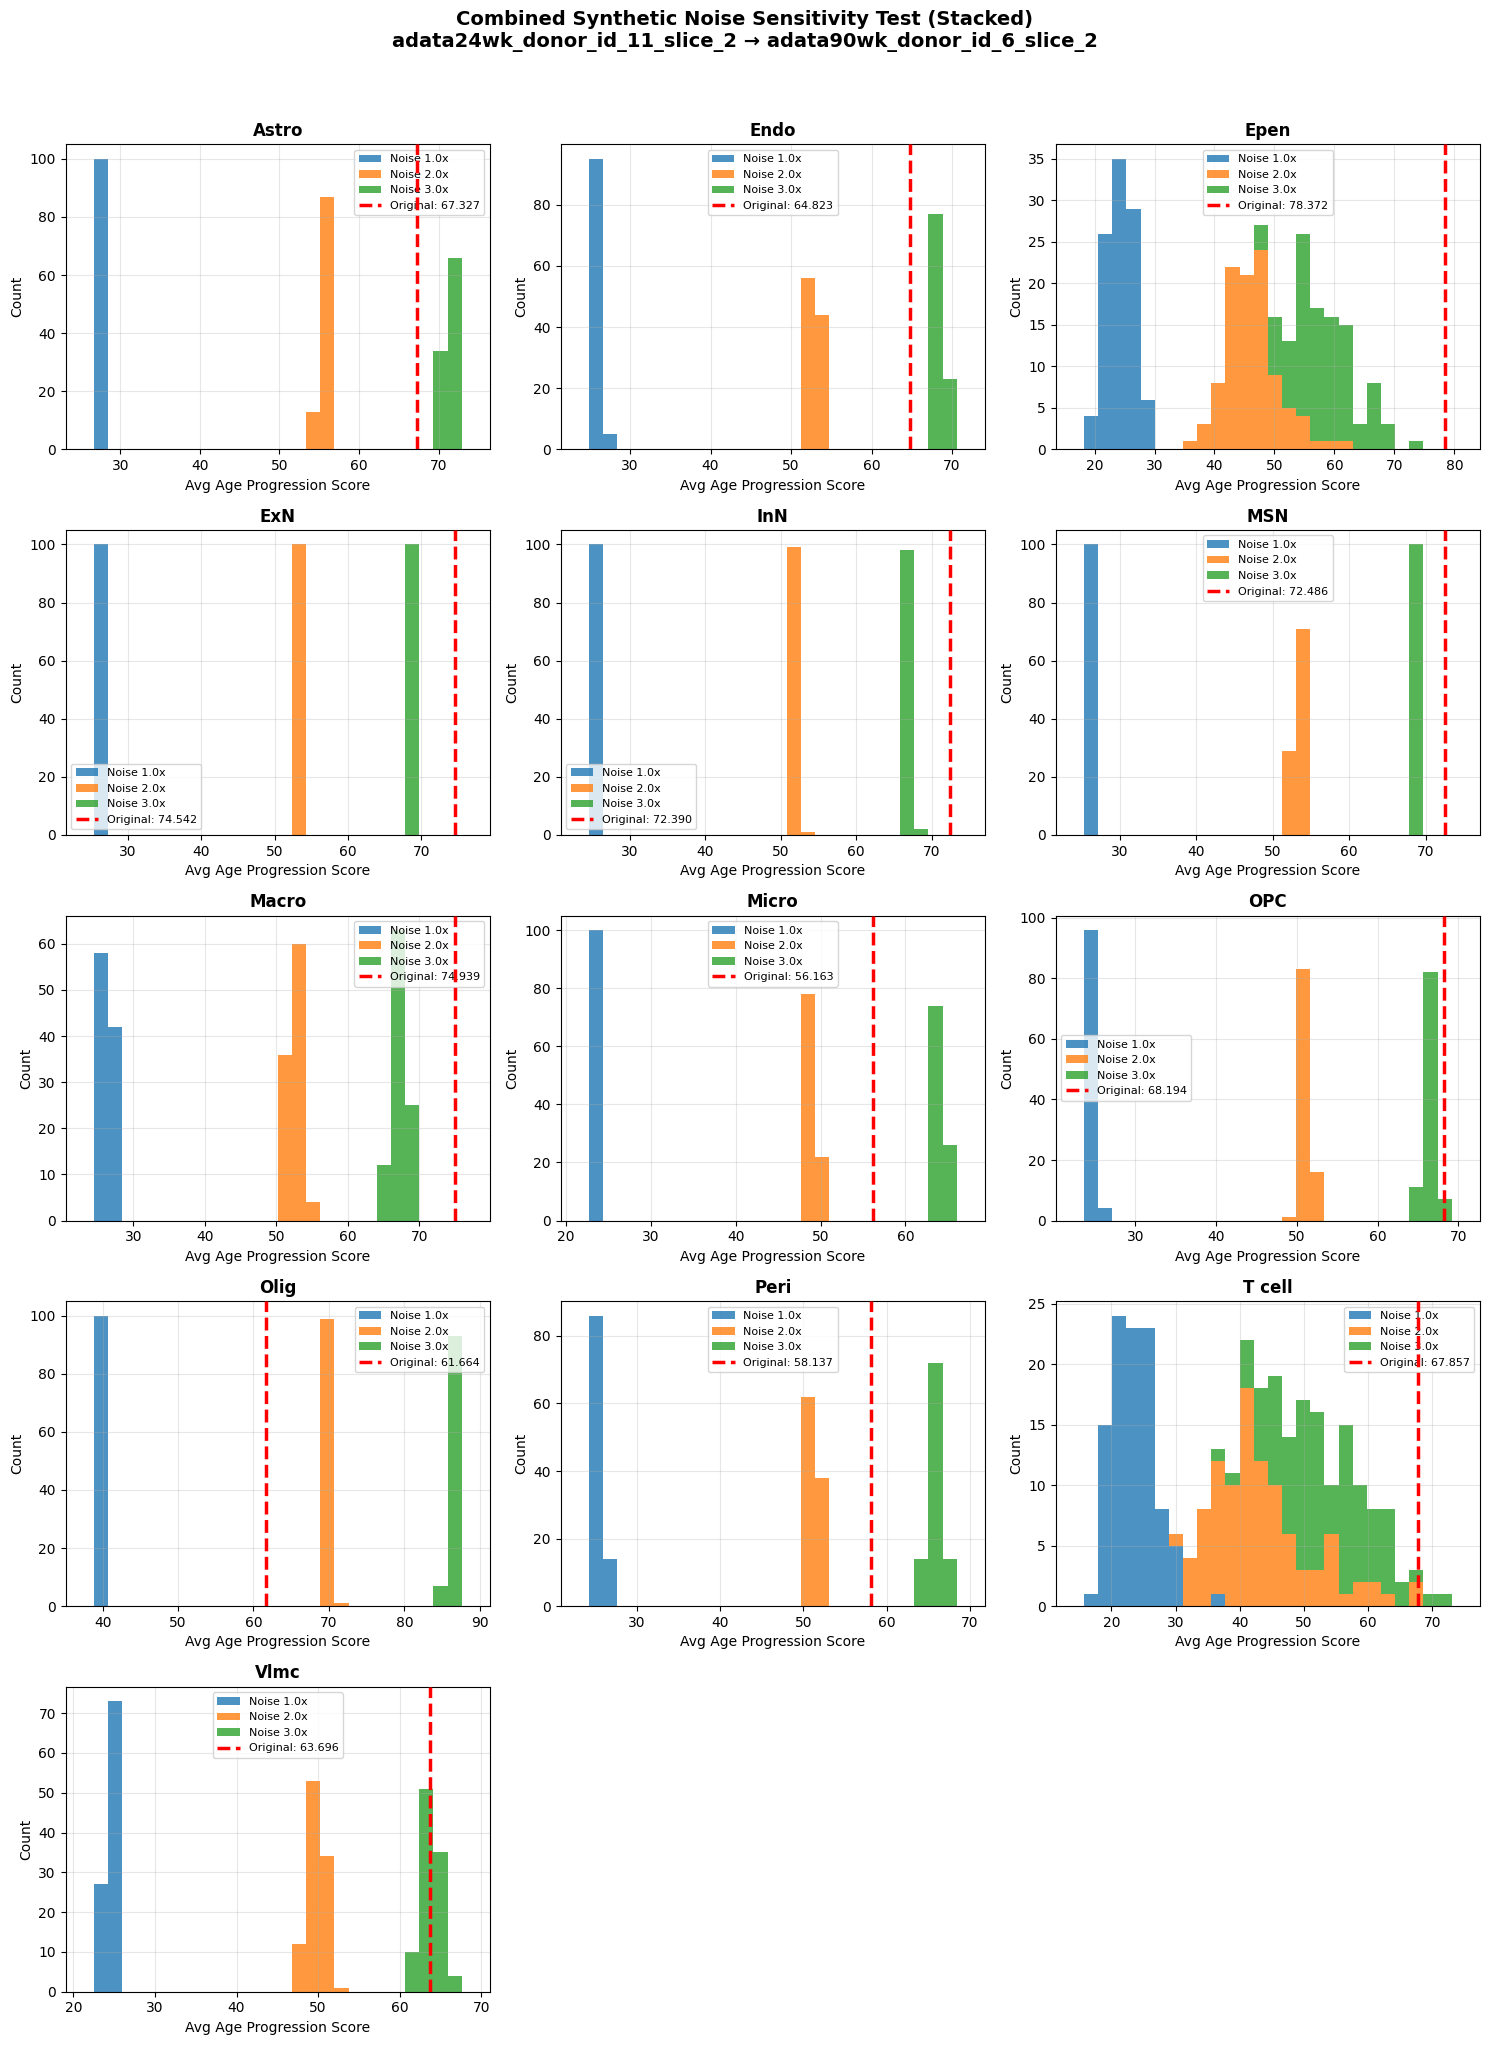



ALL COMBINED PAIRS COMPLETED


In [13]:
# ============================================================
# RUN COMBINED GENE-SPECIFIC TEST FOR ALL PAIRS
# ============================================================

all_results_combined = {}

for pair_idx, pair in enumerate(SAMPLE_PAIRS_GENE):
    print(f"\n\n{'#'*80}")
    print(f"# PROCESSING PAIR {pair_idx + 1}/{len(SAMPLE_PAIRS_GENE)} COMBINED")
    print(f"# {pair['description']}")
    print(f"{'#'*80}\n")
    
    results = gene_specific_cell_type_noise_test_combined(
        source_name=pair['source'],
        target_name=pair['target'],
        data_dir=DATA_DIR,
        n_synthetic=N_SYNTHETIC_GENE,
        noise_multipliers=NOISE_LEVELS_GENE,
        beta=BETA,
        random_seed=RANDOM_SEED_GENE,
        save_dir=SAVE_DIR,
        ot_params={
            'beta': BETA, 'alpha': 0.1, 'numItermax': 200, 'use_gpu': True
        }
    )
    
    pair_key = f"{pair['source']}_vs_{pair['target']}"
    all_results_combined[pair_key] = results
    
    save_fig_path = os.path.join(SAVE_DIR, f"combined_noise_{pair['source']}_{pair['target']}.png")
    visualize_combined_noise_test(results, save_path=save_fig_path)
    gc.collect()

print(f"\n\n{'='*80}")
print(f"ALL COMBINED PAIRS COMPLETED")
print(f"{'='*80}")

